### Regression Exercise 
# Moneyball The NBA
---

### This HW is not easy. TRY IT YOURSELF FIRST! 
Then If you are able to complete it, [watch this lecture series on it](https://ocw.mit.edu/courses/15-071-the-analytics-edge-spring-2017/pages/linear-regression/playing-moneyball-in-the-nba-recitation/video-1-the-data/). 

In [1]:
# PANDAS IS FOR DATA WRANGLING
import pandas as pd
import numpy as np

# SEABORN IS A PLOTTING LIBRARY
import seaborn as sns

# MATPLOT LIB IS ALSO A PLOTTING LIBRARY
import matplotlib.pyplot as plt

# SKLEARN IS OUR MACHINE LEARNING PACKAGE
from sklearn.linear_model import LinearRegression

# IMPORT OUR RANDOM FOREST REGERSSOR
from sklearn.ensemble import RandomForestRegressor

# METRICS HELP US SCORE OUR MODEL
from sklearn import metrics

# HELP US SPLIT OUR DATA INTO TESTING A TRAINING
from sklearn.model_selection import train_test_split

# Good ol statsmodels
import statsmodels.api as sm

# Specific root mean squared error for stats models
from statsmodels.tools.eval_measures import rmse


from statsmodels.stats.outliers_influence import variance_inflation_factor


from statsmodels.api import qqplot


# Remember our main steps motto _isbe_.
1. i - Inspect and explore data.
2. s - Select and engineer features.
3. b - Build and train model.
4. e - Evaluate model.

# STEP 1 (i): Inspect and explore data
1. Use `data/NBA_test.csv and data/NBA_train.csv`

In [2]:
# READ IN THE DATA USING PANDAS 
df = pd.read_csv('../data/NBA_train.csv')


# DISPLAY THE FIRST 5 ROWS
df.head()

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
0,1980,Atlanta Hawks,1,50,8573,8334,3261,7027,3248,6952,13,75,2038,2645,1369,2406,1913,782,539,1495
1,1980,Boston Celtics,1,61,9303,8664,3617,7387,3455,6965,162,422,1907,2449,1227,2457,2198,809,308,1539
2,1980,Chicago Bulls,0,30,8813,9035,3362,6943,3292,6668,70,275,2019,2592,1115,2465,2152,704,392,1684
3,1980,Cleveland Cavaliers,0,37,9360,9332,3811,8041,3775,7854,36,187,1702,2205,1307,2381,2108,764,342,1370
4,1980,Denver Nuggets,0,30,8878,9240,3462,7470,3379,7215,83,255,1871,2539,1311,2524,2079,746,404,1533


```
SeasonEnd: Year season ended
Team: Name of team
Playoffs: If they made the playoffs. 1 == made to playoffs
W: Number of regular season in that season. 
PTS: Points scored in regular season. 
oppPTS: Opponent Points scored in regular season. 
FG: Field Goals made (total shots made == 2P and 3P combined)
FGA: Field Goals attempted (total shots attempted == 2P and 3P combined)
2P: two-pointers made
2PA: two-pointers attempted
3P: three-pointers made
3PA: three-pointers attempted
FT: Free-Throws made (not included in FG stat)
FTA: Free-Throws attempted (not included in FG stat)
ORB: Offensive Rebounds
DRB: Defensive Rebounds
AST: Assists made
STL: Steals 
BLK: Blocks 
TOV: Turnovers 
```

#### Inspect our data using `df.describe()` function.

In [3]:
# Inspect our data using `df.describe()` function.
df.describe()

,SeasonEnd,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,1996.319760,0.574850,41.000000,8370.239521,8370.239521,3200.367665,6873.318563,2881.324551,5956.444311,319.043114,916.874251,1650.461078,2189.953293,1061.584431,2427.354491,1912.112575,668.364072,419.805988,1302.837126
std,9.243808,0.494662,12.740822,581.040114,587.543959,287.181266,401.027166,446.097941,830.596327,199.698941,523.982964,197.651728,244.491086,150.224519,130.671523,221.610925,93.393044,82.274913,153.973470
min,1980.000000,0.000000,11.000000,6901.000000,6909.000000,2565.000000,5972.000000,1981.000000,4153.000000,10.000000,75.000000,1189.000000,1475.000000,639.000000,2044.000000,1423.000000,455.000000,204.000000,931.000000
25%,1989.000000,0.000000,31.000000,7934.000000,7934.000000,2974.000000,6563.500000,2510.000000,5269.000000,131.500000,413.000000,1502.500000,2008.000000,953.500000,2346.500000,1735.000000,599.000000,359.000000,1192.000000
50%,1996.000000,1.000000,42.000000,8312.000000,8365.000000,3150.000000,6831.000000,2718.000000,5706.000000,329.000000,942.000000,1628.000000,2176.000000,1055.000000,2433.000000,1899.000000,658.000000,410.000000,1289.000000
75%,2005.000000,1.000000,50.500000,8784.500000,8768.500000,3434.500000,7157.000000,3296.000000,6753.500000,481.500000,1347.500000,1781.000000,2352.000000,1167.000000,2516.500000,2077.500000,729.000000,469.500000,1395.500000
max,2011.000000,1.000000,72.000000,10371.000000,10723.000000,3980.000000,8868.000000,3954.000000,7873.000000,841.000000,2284.000000,2388.000000,3051.000000,1520.000000,2753.000000,2575.000000,1053.000000,716.000000,1873.000000


#### Check for Nulls.

In [4]:
# Check for Nulls.
df.isna().sum()

SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64

#### Check for Duplicates

In [5]:
# Check for Duplicates
df.duplicated().sum()

np.int64(0)

#### Build a function that will INSPECT ANY DATAFRAME FOR YOU do this for you for any data frame you pass into it.

In [6]:
def inspect_dataframe(input_df):
    print("#" * 70)
    print("DATAFRAME INSPECTION REPORT")
    print("#" * 70)

    # Shape
    print(f"\nShape: {input_df.shape[0]} rows × {input_df.shape[1]} columns")

    # Missing values
    print("\n--- Missing Values ---")
    print(input_df.isnull().sum().to_string())

    # Duplicate rows
    print("\n--- Duplicate Rows ---")
    print(f"{input_df.duplicated().sum()} duplicate rows found")

    # Data types
    print("\n--- Data Types ---")
    print(input_df.dtypes.to_string())

    # Summary statistics
    print("\n--- Summary Statistics ---")
    display(input_df.describe().T.round(2))

    print("#" * 70)
    print("End of Report")
    print("#" * 70)




In [7]:
inspect_dataframe(df)

######################################################################
DATAFRAME INSPECTION REPORT
######################################################################

Shape: 835 rows × 20 columns

--- Missing Values ---
SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0

--- Duplicate Rows ---
0 duplicate rows found

--- Data Types ---
SeasonEnd     int64
Team         object
Playoffs      int64
W             int64
PTS           int64
oppPTS        int64
FG            int64
FGA           int64
2P            int64
2PA           int64
3P            int64
3PA           int64
FT            int64
FTA           int64
ORB           int64
DRB           int64
AST           int64
STL           int64
BLK           int64
TOV           int64

--- Summ

,count,mean,std,min,25%,50%,75%,max
SeasonEnd,835.0,1996.32,9.24,1980.0,1989.0,1996.0,2005.0,2011.0
Playoffs,835.0,0.57,0.49,0.0,0.0,1.0,1.0,1.0
W,835.0,41.00,12.74,11.0,31.0,42.0,50.5,72.0
PTS,835.0,8370.24,581.04,6901.0,7934.0,8312.0,8784.5,10371.0
oppPTS,835.0,8370.24,587.54,6909.0,7934.0,8365.0,8768.5,10723.0
FG,835.0,3200.37,287.18,2565.0,2974.0,3150.0,3434.5,3980.0
FGA,835.0,6873.32,401.03,5972.0,6563.5,6831.0,7157.0,8868.0
2P,835.0,2881.32,446.10,1981.0,2510.0,2718.0,3296.0,3954.0
2PA,835.0,5956.44,830.60,4153.0,5269.0,5706.0,6753.5,7873.0
3P,835.0,319.04,199.70,10.0,131.5,329.0,481.5,841.0


######################################################################
End of Report
######################################################################


#### Get a sense of how many wins it will take to make the playoffs. 
Make a scatter plot with x=Wins and the y=Team, and the hue=Playoffs

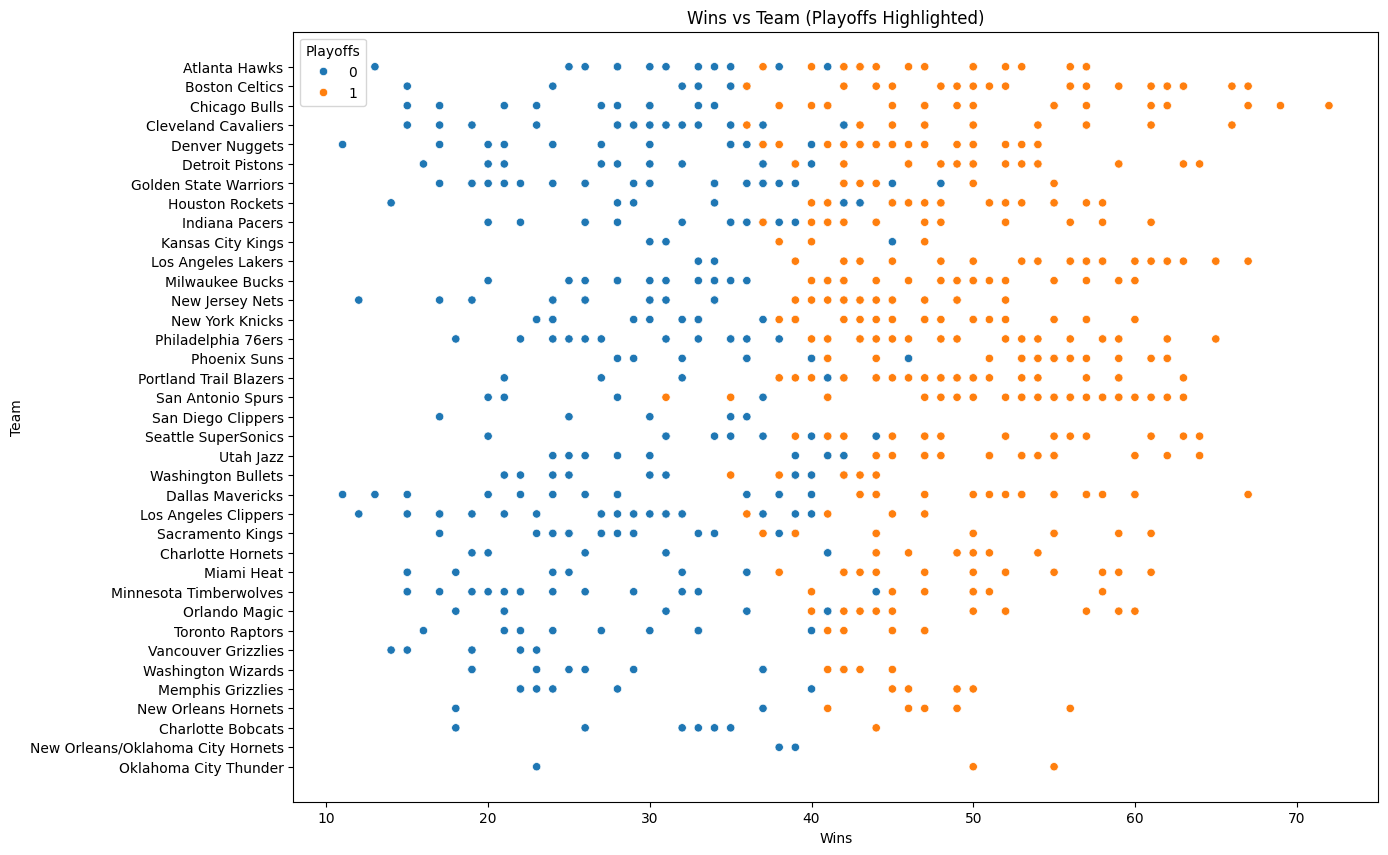

In [8]:
plt.figure(figsize=(14, 10))
sns.scatterplot(data=df, x='W', y='Team', hue='Playoffs')
plt.title('Wins vs Team (Playoffs Highlighted)')
plt.xlabel('Wins')
plt.ylabel('Team')
plt.show()


#### Take a rough estimate, and now use that moving forward.  



In [9]:
WINS_NEED_TO_MAKE_PLAYOFFS = 40

---

# Now do moneyball but for the NBA. 

#### I would like you to do try and do this on your own first.  

It's not easy, but its fun af.  

There is a guided lecture on how to do this that I can send you, but I'd like for you to try and figure it out on your own first.  

If you are fully stuck, ask in slack how other people did it if that doesn't work (I highly encourage collorbration and learning from eachother.  I still consider that doing it on your own.)  

If that doesn't work, DM me and I will send you the lectures explaining how to do the whole thing.

# Rough Guide a v1 model.
0. Make a model to predict PTS 
0. For v1, dont use `2P, 3P, FG, or FT`.  Instead use `2PA, 3PA, FTA`.  
0. Include any other cols use see fit.  


In [10]:
df.head()

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
0,1980,Atlanta Hawks,1,50,8573,8334,3261,7027,3248,6952,13,75,2038,2645,1369,2406,1913,782,539,1495
1,1980,Boston Celtics,1,61,9303,8664,3617,7387,3455,6965,162,422,1907,2449,1227,2457,2198,809,308,1539
2,1980,Chicago Bulls,0,30,8813,9035,3362,6943,3292,6668,70,275,2019,2592,1115,2465,2152,704,392,1684
3,1980,Cleveland Cavaliers,0,37,9360,9332,3811,8041,3775,7854,36,187,1702,2205,1307,2381,2108,764,342,1370
4,1980,Denver Nuggets,0,30,8878,9240,3462,7470,3379,7215,83,255,1871,2539,1311,2524,2079,746,404,1533


In [11]:
# v1: predict PTS using attempts only
features_v1 = ['2PA', '3PA', 'FTA']
y = df['PTS']
X = sm.add_constant(df[features_v1])

X.head()

,const,2PA,3PA,FTA
0,1.0,6952,75,2645
1,1.0,6965,422,2449
2,1.0,6668,275,2592
3,1.0,7854,187,2205
4,1.0,7215,255,2539


### Finding 1: Version 1 – Basic Shot Attempts Model (PTS Prediction)

The adjusted R² is 0.791, which means the model explains about 79% of the variation in team points.  
The coefficients for 2PA, 3PA, and FTA are 1.0415, 1.2360, and 1.1282, showing that more shot attempts lead to higher total points.  
All p-values are 0.000, meaning each variable is statistically significant.


In [12]:
# fit the OLS model to predict PTS
model_pts_v1 = sm.OLS(y, X).fit()
y_pred_v1 = model_pts_v1.predict(X)

print(model_pts_v1.summary())

                            OLS Regression Results                            
Dep. Variable:                    PTS   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     1050.
Date:                Wed, 22 Oct 2025   Prob (F-statistic):          3.63e-282
Time:                        17:13:57   Log-Likelihood:                -5844.7
No. Observations:                 835   AIC:                         1.170e+04
Df Residuals:                     831   BIC:                         1.172e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1436.9955    230.032     -6.247      0.0

# Version 2

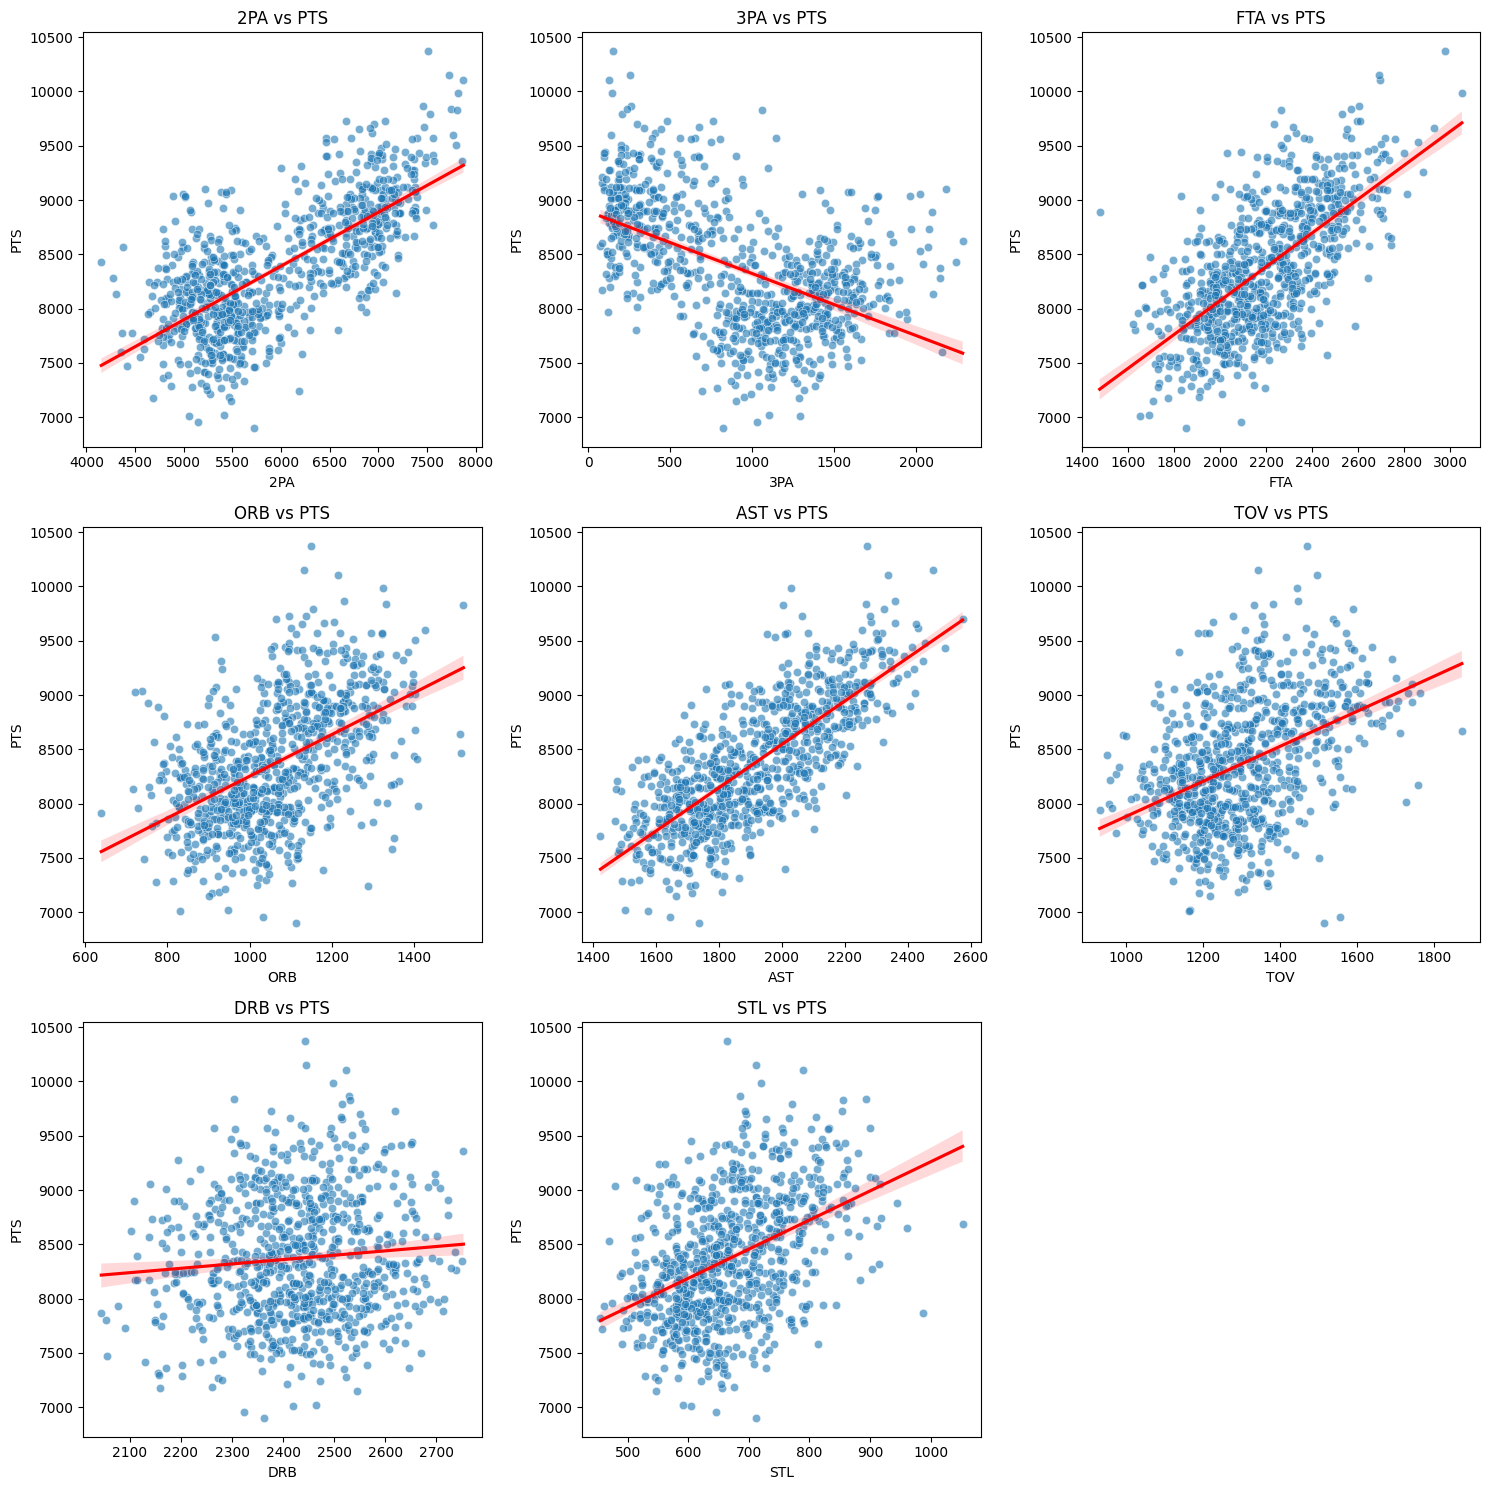

In [26]:
# plot scatter + regression lines for each feature vs PTS

dependent_variable = 'PTS'
independent_variables = ['2PA', '3PA', 'FTA', 'ORB', 'AST', 'TOV', 'DRB', 'STL']

n = len(independent_variables)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()

for i, var in enumerate(independent_variables):
    sns.scatterplot(x=df[var], y=df[dependent_variable], ax=axes[i], alpha=0.6)
    sns.regplot(x=df[var], y=df[dependent_variable], ax=axes[i], scatter=False, color='red')
    axes[i].set_title(f'{var} vs {dependent_variable}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel(dependent_variable)

# remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Finding 2: Version 2 – Improved Offensive Model

This model predicts team points (PTS) using 2PA, 3PA, FTA, AST, and TOV.  
The adjusted R² is 0.876, meaning the model explains about 88 percent of the variation in team scoring.  
All variables are statistically significant with p-values below 0.01.  
The coefficients show that more two-point attempts, three-point attempts, free-throw attempts, and assists lead to higher points, while turnovers lower total points.  
This version provides a strong and logical explanation of how offensive actions translate into total team scoring.


In [14]:
# v2 model: predicting PTS using best selected features
features_v2 = ['2PA', '3PA', 'FTA', 'AST', 'TOV']
y = df['PTS']
X = sm.add_constant(df[features_v2])

# fit the model
model_pts_v2 = sm.OLS(y, X).fit()
y_pred_v2 = model_pts_v2.predict(X)

# print the summary
print(model_pts_v2.summary())


                            OLS Regression Results                            
Dep. Variable:                    PTS   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     1167.
Date:                Wed, 22 Oct 2025   Prob (F-statistic):               0.00
Time:                        17:13:57   Log-Likelihood:                -5628.9
No. Observations:                 835   AIC:                         1.127e+04
Df Residuals:                     829   BIC:                         1.130e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1460.2553    190.260     -7.675      0.0

# Predicting Wins using Point Differential



In [15]:
df['point_diff'] = df['PTS'] - df['oppPTS']
df.head()

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,...,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV,point_diff
0,1980,Atlanta Hawks,1,50,8573,8334,3261,7027,3248,6952,...,75,2038,2645,1369,2406,1913,782,539,1495,239
1,1980,Boston Celtics,1,61,9303,8664,3617,7387,3455,6965,...,422,1907,2449,1227,2457,2198,809,308,1539,639
2,1980,Chicago Bulls,0,30,8813,9035,3362,6943,3292,6668,...,275,2019,2592,1115,2465,2152,704,392,1684,-222
3,1980,Cleveland Cavaliers,0,37,9360,9332,3811,8041,3775,7854,...,187,1702,2205,1307,2381,2108,764,342,1370,28
4,1980,Denver Nuggets,0,30,8878,9240,3462,7470,3379,7215,...,255,1871,2539,1311,2524,2079,746,404,1533,-362


### Finding 3: Point Differential as a Predictor of Wins

The model shows a very strong relationship between point differential and team wins.  
The adjusted R² is 0.942, meaning the model explains about 94 percent of the variation in wins.  
The coefficient for point_diff is 0.0326, showing that for each one-point increase in point differential, wins increase by about 0.03.  
The p-value is 0.000, confirming that point_diff is a statistically significant predictor of wins.


In [16]:
# Build an OLS model to predict Wins using point_diff
X = sm.add_constant(df[['point_diff']])
y = df['W']

model_wins = sm.OLS(y, X).fit()
y_pred = model_wins.predict(X)

print(model_wins.summary())


                            OLS Regression Results                            
Dep. Variable:                      W   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                 1.361e+04
Date:                Wed, 22 Oct 2025   Prob (F-statistic):               0.00
Time:                        17:13:58   Log-Likelihood:                -2118.0
No. Observations:                 835   AIC:                             4240.
Df Residuals:                     833   BIC:                             4249.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.0000      0.106    387.027      0.0

### Finding 4: Point Differential Needed to Reach the Playoffs

Based on the regression equation, a team needs a point differential of about -31 to reach 40 wins.  
This means teams can make the playoffs even if they allow slightly more points than they score,  
showing that small differences in total points do not always reflect overall season success.

In [17]:
b = model_wins.params['const']       # intercept
m = model_wins.params['point_diff']  # slope

required_point_diff = (WINS_NEED_TO_MAKE_PLAYOFFS - b) / m
print("Point differential needed for playoffs:", round(required_point_diff, 2))

Point differential needed for playoffs: -30.69


### Finding 5: Predicting Playoff Probability from Wins

The logistic regression model shows a strong relationship between wins and playoff chances.  
The R² is 0.7287, meaning the model explains about 73 percent of the variation in playoff outcomes.  
The coefficient for wins is 0.4719, showing that as a team’s wins increase, the probability of making the playoffs rises sharply.  
The p-value is 0.000, confirming that wins are a statistically significant predictor of playoff success.

In [18]:
# Build a logistic regression model to predict Playoff chances using Wins
X = sm.add_constant(df[['W']])
y = df['Playoffs']

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.184967
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:               Playoffs   No. Observations:                  835
Model:                          Logit   Df Residuals:                      833
Method:                           MLE   Df Model:                            1
Date:                Wed, 22 Oct 2025   Pseudo R-squ.:                  0.7287
Time:                        17:13:58   Log-Likelihood:                -154.45
converged:                       True   LL-Null:                       -569.39
Covariance Type:            nonrobust   LLR p-value:                1.723e-182
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -18.4806      1.621    -11.398      0.000     -21.658     -15.303
W              0.4719      0.

### Finding 6: Wins Needed for a 50% Playoff Chance

According to the logistic regression model, a team needs about 39 wins to have a 50 percent chance of making the playoffs.  
This aligns closely with the earlier linear regression results, confirming that around 40 wins is the general playoff threshold.


In [19]:
# Calculate the number of wins for a 50% playoff probability
intercept = logit_model.params['const']
coef_wins = logit_model.params['W']

wins_for_50 = -(intercept / coef_wins)
print("Wins needed for a 50% playoff probability:", round(wins_for_50, 2))


Wins needed for a 50% playoff probability: 39.16


# Logistic Regression

### Finding 7: Visualizing Playoff Probability by Wins

The playoff probability curve shows that teams with fewer than 35 wins have almost no chance of making the playoffs.  
The probability rises sharply around 39 to 40 wins, reaching about 50 percent.  
After 50 wins, nearly every team qualifies, confirming that around 40 wins is the typical playoff cutoff.

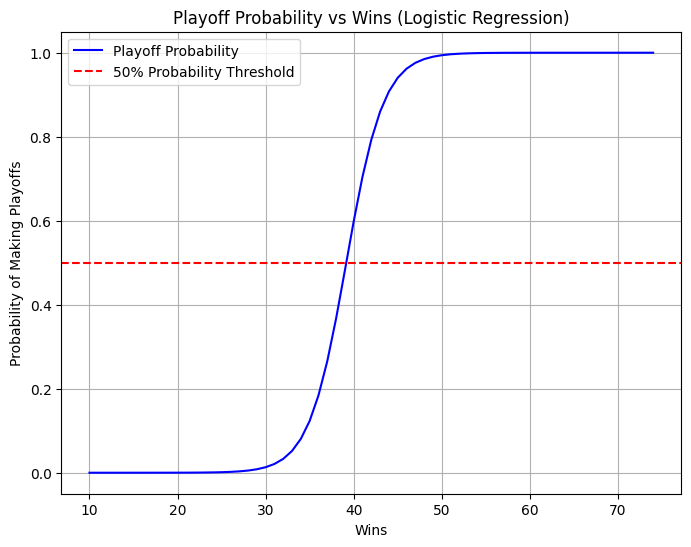

In [21]:
# Create a range of wins for prediction
wins_range = pd.DataFrame({'W': range(10, 75)})
wins_range = sm.add_constant(wins_range)

# Predict playoff probabilities
wins_range['Playoff_Probability'] = logit_model.predict(wins_range)

# Plot the curve
plt.figure(figsize=(8,6))
plt.plot(wins_range['W'], wins_range['Playoff_Probability'], color='blue', label='Playoff Probability')
plt.axhline(0.5, color='red', linestyle='--', label='50% Probability Threshold')
plt.xlabel('Wins')
plt.ylabel('Probability of Making Playoffs')
plt.title('Playoff Probability vs Wins (Logistic Regression)')
plt.legend()
plt.grid(True)
plt.show()


# HOW TO WIN 50 GAMES

In [29]:
WINS_TARGET = 50

b = model_wins.params['const']
m = model_wins.params['point_diff']

required_point_diff_50 = (WINS_TARGET - b) / m
print("Point differential needed for 50 wins:", round(required_point_diff_50, 2))


Point differential needed for 50 wins: 276.19


In [30]:
# average opponent points in the dataset
avg_opp_pts = df['oppPTS'].mean()

# calculate required PTS
required_pts_50 = avg_opp_pts + required_point_diff_50
print("Points needed for 50 wins:", round(required_pts_50, 2))

Points needed for 50 wins: 8646.43


In [32]:
print(model_pts_v2.params)


const   -1460.255339
2PA         0.804683
3PA         1.092699
FTA         1.039618
AST         1.043243
TOV        -0.181092
dtype: float64


### Finding 8: Points Needed to Reach 50 Wins

The average team is predicted to score about 8,370 points in a season.  
To reach 50 wins, a team needs to score around 8,646 points, about 276 points more.  
This means a team must improve its offense by roughly 3 to 4 points per game to reach a guaranteed playoff level.


In [33]:
# get average team stats
team_means = df[['2PA', '3PA', 'FTA', 'AST', 'TOV']].mean()
print(team_means)

# calculate predicted PTS for the average team
avg_predicted_pts = (
    -1460.255339
    + 0.804683 * team_means['2PA']
    + 1.092699 * team_means['3PA']
    + 1.039618 * team_means['FTA']
    + 1.043243 * team_means['AST']
    - 0.181092 * team_means['TOV']
)

print("Predicted PTS for average team:", round(avg_predicted_pts, 2))
print("Extra points needed for 50 wins:", round(8646.43 - avg_predicted_pts, 2))


2PA    5956.444311
3PA     916.874251
FTA    2189.953293
AST    1912.112575
TOV    1302.837126
dtype: float64
Predicted PTS for average team: 8370.24
Extra points needed for 50 wins: 276.19


## Final Summary: Moneyball for the NBA

This analysis followed the Moneyball approach used in baseball but applied it to NBA team data.

1. Built a regression model to predict team points (PTS) from shooting and playmaking stats.  
   - The model explained about 88% of scoring variation (Adj. R² = 0.875).  
   - More 2PA, 3PA, FTA, and assists led to higher points, while turnovers reduced scoring.

2. Built a model to predict wins (W) using point differential (PTS − oppPTS).  
   - The model explained 94% of variation in team wins.  
   - Teams that outscored opponents by 276 points were expected to reach around 50 wins.

3. Built a logistic model to predict playoff chances based on wins.  
   - About 40 wins gave a 50% playoff chance, while 50 wins nearly guaranteed a spot.

4. Combined all models to estimate team targets.  
   - To reach 50 wins, a team needs roughly 8,646 total points (≈3–4 more per game than average).

Overall, the Moneyball method shows that a small boost in offensive performance can significantly increase playoff odds.

